In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
import seaborn as sns
import os
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Verification of robustness 

Vehicle code shown as:
```python
robustSafetyAround : Input -> Label -> Bool
robustSafetyAround x action = forall pertubation .
    let xPerturbed = x - pertubation in
    (boundedByEpsilon pertubation) and validInput (xPerturbed) =>
    actionToTake action xPerturbed


,epsilon,verified,falsified,total,verified_ratio
0,0.001,4850,3156,8006,0.605796
1,0.005,4834,3172,8006,0.603797
2,0.010,4812,3194,8006,0.601049
3,0.050,4614,3392,8006,0.576318
4,0.100,4464,3542,8006,0.557582


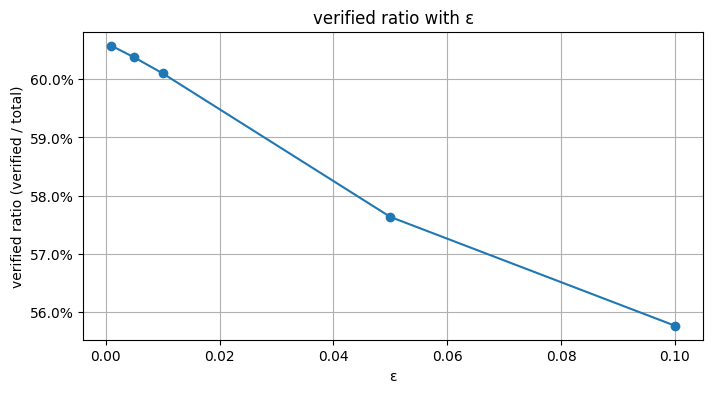

In [2]:
filename = 'robust_summary.csv'
df = pd.read_csv(filename)
display(df)
plt.figure(figsize=(8, 4))
plt.plot(df['epsilon'], df['verified_ratio'], marker='o', linestyle='-')
plt.title('verified ratio with ε')
plt.xlabel('ε')
plt.ylabel('verified ratio (verified / total)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.grid(True)

# Verification of "strongER" robustness  ¯|_(ツ)_/¯

Instead of using the definition of strong robustness：
$f(x)_i \ge \eta$，
we define strongER robustness as:
$$\forall j \neq i, f(x)_j \le \eta'$$
with softmax, this also includes:
$$
f(x)_i \ge \underbrace{1 - (n-1)\eta'}_{\eta}
$$


Vehicle code shown as:
```python
strongRobustSafetyAround : Input -> Label -> Bool
strongRobustSafetyAround x action = forall pertubation .
    let xPerturbed = x - pertubation in
    (boundedByEpsilon pertubation) and validInput (xPerturbed) =>
    smallerThanEta action xPerturbed

smallerThanEta : Index 3 -> Input -> Bool
smallerThanEta i x = forall j .
    i != j => nnModel x ! j <= eta


epsilon,0.005,0.010,0.050,0.100,0.500
eta,,,,,
0.005,0.988259,0.988259,0.986135,0.979640,0.689983
0.010,0.988259,0.988259,0.986135,0.979890,0.691981
0.050,0.988509,0.988259,0.986260,0.982513,0.702848
0.100,0.988509,0.988509,0.986385,0.984512,0.721709
0.500,0.989133,0.989133,0.987509,0.986010,0.850237


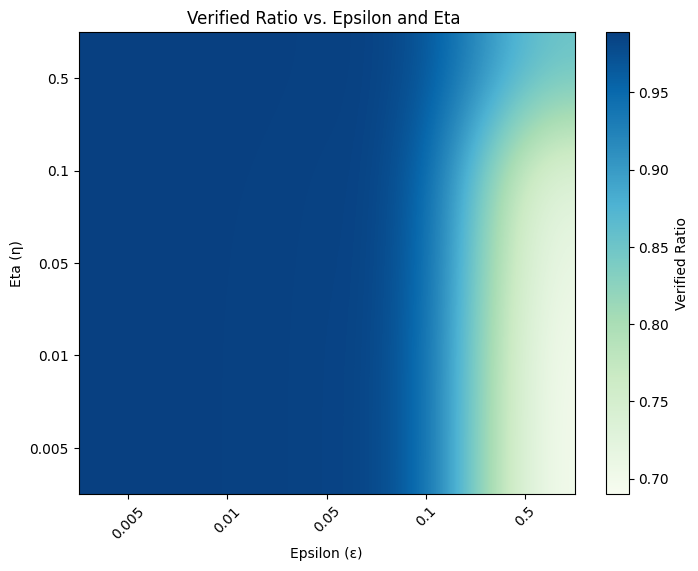

In [3]:
filename = 'strongrobust_summary.csv'
eta_col = 'eta'
epsilon_col = 'epsilon'
value_col = 'verified_ratio'

df = pd.read_csv(filename)

pivot_df = pd.pivot_table(
    df,
    index=eta_col,        
    columns=epsilon_col,   
    values=value_col        
)

pivot_df = pivot_df.sort_index(axis=0) 
pivot_df = pivot_df.sort_index(axis=1) 
display(pivot_df)

plt.figure(figsize=(8, 6))

img = plt.imshow(
    pivot_df.values,       
    interpolation='bicubic',  
    cmap='GnBu',
    aspect='auto',
    origin='lower'         
)

plt.colorbar(img, label='Verified Ratio');

plt.xticks(
    ticks=np.arange(pivot_df.shape[1]),
    labels=pivot_df.columns,           
    rotation=45
)
plt.yticks(
    ticks=np.arange(pivot_df.shape[0]), 
    labels=pivot_df.index             
)

plt.title('Verified Ratio vs. Epsilon and Eta ')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Eta (η)')
plt.show()

# Verification of Lipschitz robustness & Euclidean distance 

$$|f(x) - f(\hat{x})| \le L |x - \hat{x}|$$
```python
lipschitzRobustSafetyAround : Input -> Label -> Bool
lipschitzRobustSafetyAround x action = forall pertubation .
    let xPerturbed = x - pertubation in
    (boundedByEpsilon pertubation) and validInput (xPerturbed) =>
    -Lip <= (nnModel x ! i) - (nnModel xPerturbed ! i) <= Lip
```
$${L_2}(x, \hat{x}) = \sqrt{\sum_{i} (x_i - \hat{x}_i)^2}$$
```python
boundedByEpsilonEuclidean : UnnormalisedInput -> Bool
boundedByEpsilonEuclidean x = forall i .
    (x!i)*(x!i) <= epsilon*epsilon

```
# Can't make it work  (╯°□°）╯︵ ┻━┻
